In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
import numpy
import numpy as np
import joblib
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from matplotlib.gridspec import GridSpec
from IPython.display import display, HTML
warnings.filterwarnings('ignore')

In [4]:
field_names_path = '../data/NSL_KDD-master/Field_Names.csv'
fields_df = pd.read_csv(field_names_path, header=None, names=['name', 'type'])

# Los nombres originales del Field_Names.csv (41 columnas) - SIN CAMBIAR el primer nombre
column_names = fields_df['name'].tolist()

# Añadir las 2 columnas extras que están en los datos pero no en el CSV
column_names.append('label')        # Columna 42 - tipo de ataque/normal
column_names.append('difficulty_level')  # Columna 43 - nivel de dificultad

print(f"Total de columnas configuradas: {len(column_names)}")

# Cargar los datasets con todos los nombres correctos
train_df = pd.read_csv('../data/NSL_KDD-master/KDDTrain+.csv', names=column_names)
test_df = pd.read_csv('../data/NSL_KDD-master/KDDTest+.csv', names=column_names)
subset_df = pd.read_csv('../data/NSL_KDD-master/20_Percent_Training_Set.csv', names=column_names)

# Cargar Attack_Types correctamente
attack_types_df = pd.read_csv('../data/NSL_KDD-master/Attack_Types.csv', 
                             header=None, 
                             names=['attack_name', 'attack_category'])

# Configurar pandas para mejor visualización sin solapamiento
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)  # Ancho más grande para evitar solapamiento
pd.set_option('display.max_colwidth', 40)  # Máximo ancho por columna
pd.set_option('display.colheader_justify', 'left')  # Alinear encabezados

# Función para mostrar datos de manera interactiva
def mostrar_datos_interactivo():
    respuesta = input("¿Quieres ver los datos? (si/no): ").lower().strip()
    
    if respuesta in ['si', 'sí', 's', 'yes', 'y']:
        print("\n" + "="*100)
        print("RESUMEN DE DATASETS:")
        print(f"KDDTrain+: {train_df.shape[0]} filas, {train_df.shape[1]} columnas")
        print(f"KDDTest+: {test_df.shape[0]} filas, {test_df.shape[1]} columnas")
        print(f"20_Percent_Training_Set: {subset_df.shape[0]} filas, {subset_df.shape[1]} columnas")
        print(f"Attack_Types: {attack_types_df.shape[0]} filas, {attack_types_df.shape[1]} columnas")
        
        # Preguntar cuántas filas quiere ver
        max_filas = min(train_df.shape[0], test_df.shape[0], subset_df.shape[0])
        
        while True:
            try:
                filas_a_mostrar = int(input(f"\n¿Cuántas filas quieres ver? (máximo {max_filas}): "))
                if 0 <= filas_a_mostrar <= max_filas:
                    break
                else:
                    print(f"Por favor, ingresa un número entre 0 y {max_filas}")
            except ValueError:
                print("Por favor, ingresa un número válido")
        
        if filas_a_mostrar > 0:
            print("\n" + "="*100)
            print("=== KDDTrain+ ===")
            print(f"Dimensiones: {train_df.shape}")
            display(train_df.head(filas_a_mostrar))

            print("\n" + "="*100)
            print("=== KDDTest+ ===")
            print(f"Dimensiones: {test_df.shape}")
            display(test_df.head(filas_a_mostrar))

            print("\n" + "="*100)
            print("=== 20_Percent_Training_Set ===")
            print(f"Dimensiones: {subset_df.shape}")
            display(subset_df.head(filas_a_mostrar))

            print("\n" + "="*100)
            print("=== Attack_Types ===")
            print(f"Dimensiones: {attack_types_df.shape}")
            display(attack_types_df.head(filas_a_mostrar))

            print("\n" + "="*100)
            print("=== VERIFICACIÓN DE COLUMNAS ===")
            print(f"Primera columna: '{train_df.columns[0]}'")
            print(f"Últimas 5 columnas: {list(train_df.columns[-5:])}")
            print(f"¿Contiene 'difficulty_level'?: {'difficulty_level' in train_df.columns}")
        else:
            print("No se mostrarán datos.")
    else:
        print("No se mostrarán los datos.")

# Llamar a la función interactiva
mostrar_datos_interactivo()

Total de columnas configuradas: 43


¿Quieres ver los datos? (si/no):  no


No se mostrarán los datos.


In [5]:
def analizar_dataset_completo(df, nombre="Dataset"):
    """
    Análisis completo sin omitir ningún dato - CON SCROLL
    """
    # Crear contenedor con scroll
    display(HTML(f"<div style='max-height: 600px; overflow-y: auto; border: 1px solid #ccc; padding: 10px; background: #f5f5f5;'>"))
    
    print(f"\n{'='*100}")
    print(f"ANÁLISIS COMPLETO: {nombre}")
    print(f"{'='*100}")
    print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]:,}")
    
    # Análisis de todas las columnas una por una
    for columna in df.columns:
        _analizar_columna_completa(df, columna)
    
    display(HTML("</div>"))

def _analizar_columna_completa(df, columna):
    """Análisis completo de una columna sin omitir datos"""
    print(f"\n{'─'*80}")
    print(f"COLUMNA: {columna}")
    print(f"{'─'*80}")
    
    datos = df[columna]
    nulos = datos.isnull().sum()
    total = len(df)
    no_nulos = total - nulos
    
    print(f"Tipo: {datos.dtype}")
    print(f"Total registros: {total:,}")
    print(f"No nulos: {no_nulos:,} ({no_nulos/total*100:.1f}%)")
    print(f"Nulos: {nulos:,} ({nulos/total*100:.1f}%)")
    print(f"Valores únicos: {datos.nunique()}")
    
    if np.issubdtype(datos.dtype, np.number):
        _analizar_numerica_completa(df, columna)
    else:
        _analizar_categorica_completa(df, columna)

def _analizar_numerica_completa(df, columna):
    """Análisis completo para columna numérica"""
    datos = df[columna].dropna()
    
    if len(datos) == 0:
        print("Sin datos numéricos para analizar")
        return
    
    # Estadísticas descriptivas
    q1, q2, q3 = np.percentile(datos, [25, 50, 75])
    
    print(f"\nESTADÍSTICAS:")
    print(f"  Media: {datos.mean():.4f}")
    print(f"  Mediana: {datos.median():.4f}")
    print(f"  Desviación estándar: {datos.std():.4f}")
    print(f"  Mínimo: {datos.min():.4f}")
    print(f"  Máximo: {datos.max():.4f}")
    print(f"  Rango: {datos.max() - datos.min():.4f}")
    print(f"  Q1 (25%): {q1:.4f}")
    print(f"  Q2 (50%): {q2:.4f}")
    print(f"  Q3 (75%): {q3:.4f}")
    print(f"  IQR: {q3 - q1:.4f}")
    
    # Histograma completo
    print(f"\nDISTRIBUCIÓN (histograma):")
    try:
        hist, bins = np.histogram(datos, bins=min(20, len(np.unique(datos))))
        max_hist = max(hist) if len(hist) > 0 else 1
        
        for i in range(len(hist)):
            if hist[i] > 0:
                barra = "█" * max(1, int(hist[i] / max_hist * 50))
                bin_range = f"{bins[i]:.2f}-{bins[i+1]:.2f}"
                print(f"  {bin_range:<20} {hist[i]:>6} {barra}")
    except Exception as e:
        print(f"  No se pudo generar histograma: {e}")

def _analizar_categorica_completa(df, columna):
    """Análisis completo para columna categórica - muestra TODOS los valores"""
    value_counts = df[columna].value_counts()
    total_no_nulos = len(df) - df[columna].isnull().sum()
    
    print(f"\nDISTRIBUCIÓN COMPLETA ({len(value_counts)} valores):")
    
    for i, (valor, count) in enumerate(value_counts.items(), 1):
        porcentaje = (count / total_no_nulos * 100) if total_no_nulos > 0 else 0
        barra = "█" * max(1, int(porcentaje / 2))
        valor_str = str(valor)
        
        print(f"  {i:3d}. {valor_str:<35} {count:>8} ({porcentaje:6.2f}%) {barra}")
    
    # Estadísticas de diversidad
    if len(value_counts) > 1:
        print(f"\nESTADÍSTICAS DE DIVERSIDAD:")
        print(f"  Valor más frecuente: '{value_counts.index[0]}' ({value_counts.iloc[0]/total_no_nulos*100:.2f}%)")
        print(f"  Valor menos frecuente: '{value_counts.index[-1]}' ({value_counts.iloc[-1]/total_no_nulos*100:.2f}%)")
        if len(value_counts) > 1:
            print(f"  Ratio dominancia: {value_counts.iloc[0]/value_counts.iloc[1]:.2f}x")

def ejecutar_analisis_interactivo():
    """Función que pregunta al usuario si quiere ejecutar el análisis"""
    respuesta = input("¿Quieres ejecutar el análisis completo de los datasets? (si/no): ").lower().strip()
    
    if respuesta in ['si', 'sí', 's', 'yes', 'y']:
        print("Iniciando análisis completo...")
        max_columnas = None
        
        # Ejecutar análisis con o sin límite
        if max_columnas and max_columnas > 0:
            print(f"Analizando las primeras {max_columnas} columnas de cada dataset...")
            # Crear copias con columnas limitadas
            train_limited = train_df.iloc[:, :max_columnas]
            test_limited = test_df.iloc[:, :max_columnas]
            analizar_dataset_completo(train_limited, f"TRAINING SET (primeras {max_columnas} columnas)")
            analizar_dataset_completo(test_limited, f"TEST SET (primeras {max_columnas} columnas)")
        else:
            print("Analizando todos los datasets completamente...")
            analizar_dataset_completo(train_df, "TRAINING SET COMPLETO")
            analizar_dataset_completo(test_df, "TEST SET COMPLETO")
            
        print("Análisis completado.")
    else:
        print("Análisis cancelado por el usuario.")

if __name__ == "__main__":
    # Cargar los datos
    field_names_path = '../data/NSL_KDD-master/Field_Names.csv'
    fields_df = pd.read_csv(field_names_path, header=None, names=['name', 'type'])
    
    column_names = fields_df['name'].tolist()
    column_names.append('label')
    column_names.append('difficulty_level')
    
    print(f"Analisis realizado")
    
    # Cargar datasets
    train_df = pd.read_csv('../data/NSL_KDD-master/KDDTrain+.csv', names=column_names)
    test_df = pd.read_csv('../data/NSL_KDD-master/KDDTest+.csv', names=column_names)
    
    # Ejecutar análisis de manera interactiva
    ejecutar_analisis_interactivo()

Analisis realizado


¿Quieres ejecutar el análisis completo de los datasets? (si/no):  no


Análisis cancelado por el usuario.


In [6]:
# 1. Limpieza inicial y verificación

train_df_cleaned = train_df.copy()
train_df_cleaned.columns = [col.strip().replace(' ', '_').lower() for col in train_df_cleaned.columns]

# 2. Identificar target y verificar que existe
target_column = train_df_cleaned.columns[-1]

# 4. Manejar valores nulos ANTES de separar X e y
numeric_cols = train_df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()

# Imputar valores nulos
for col in train_df_cleaned.columns:
    if train_df_cleaned[col].isnull().any():
        null_count = train_df_cleaned[col].isnull().sum()
        
        if col in numeric_cols:
            train_df_cleaned[col].fillna(train_df_cleaned[col].median(), inplace=True)
        elif col in categorical_cols:
            train_df_cleaned[col].fillna(train_df_cleaned[col].mode()[0], inplace=True)

# 5. SEPARAR X e y DESPUÉS de limpiar (IMPORTANTE)
X = train_df_cleaned.drop(columns=[target_column])
y = train_df_cleaned[target_column]


# Verificar que coinciden
if X.shape[0] != len(y):
    
    # Solución: usar índices comunes
    common_index = X.index.intersection(y.index)
    X = X.loc[common_index]
    y = y.loc[common_index]

# 6. Codificar variable objetivo
if y.dtype == 'object':
    label_encoder_y = LabelEncoder()
    y_encoded = label_encoder_y.fit_transform(y)
    joblib.dump(label_encoder_y, '../backend/label_encoder_y.pkl')
else:
    y_encoded = y.values

# 7. DIVISIÓN TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 8. CODIFICAR variables categóricas en X
label_encoders = {}
categorical_cols_x = [col for col in categorical_cols if col in X.columns]

for col in categorical_cols_x:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

joblib.dump(label_encoders, '../backend/label_encoders.pkl')

# 9. ESCALAR variables numéricas
scaler = StandardScaler()
numeric_cols_x = [col for col in numeric_cols if col in X.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

if numeric_cols_x:
    X_train_scaled[numeric_cols_x] = scaler.fit_transform(X_train[numeric_cols_x])
    X_test_scaled[numeric_cols_x] = scaler.transform(X_test[numeric_cols_x])
    joblib.dump(scaler, '../backend/scaler.pkl')
else:
    print("No hay columnas numéricas para escalar")

print(f"\n✅ PREPROCESAMIENTO COMPLETADO")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")
print(f"y_test: {y_test.shape}")


✅ PREPROCESAMIENTO COMPLETADO
X_train_scaled: (100778, 42)
y_train: (100778,)
X_test_scaled: (25195, 42)
y_test: (25195,)


In [7]:
# Verificación crítica antes de entrenar
assert X_train_scaled.shape[0] == len(y_train), f"ERROR: X_train {X_train_scaled.shape[0]} != y_train {len(y_train)}"
assert X_test_scaled.shape[0] == len(y_test), f"ERROR: X_test {X_test_scaled.shape[0]} != y_test {len(y_test)}"

print("✅ Todas las verificaciones pasadas - Puedes proceder con el modelo")

# Crear y entrenar el modelo
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Validación cruzada
print("Realizando validación cruzada...")
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5)
print(f"✅ Validación Cruzada: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Entrenar modelo final
print("Entrenando modelo final...")
rf_model.fit(X_train_scaled, y_train)

✅ Todas las verificaciones pasadas - Puedes proceder con el modelo
Realizando validación cruzada...
✅ Validación Cruzada: 0.8790 (+/- 0.0034)
Entrenando modelo final...


RandomForestClassifier(max_depth=25, max_features='log2', min_samples_leaf=2,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [8]:
y_pred = rf_model.predict(X_test_scaled)

✅ Accuracy: 88.28%


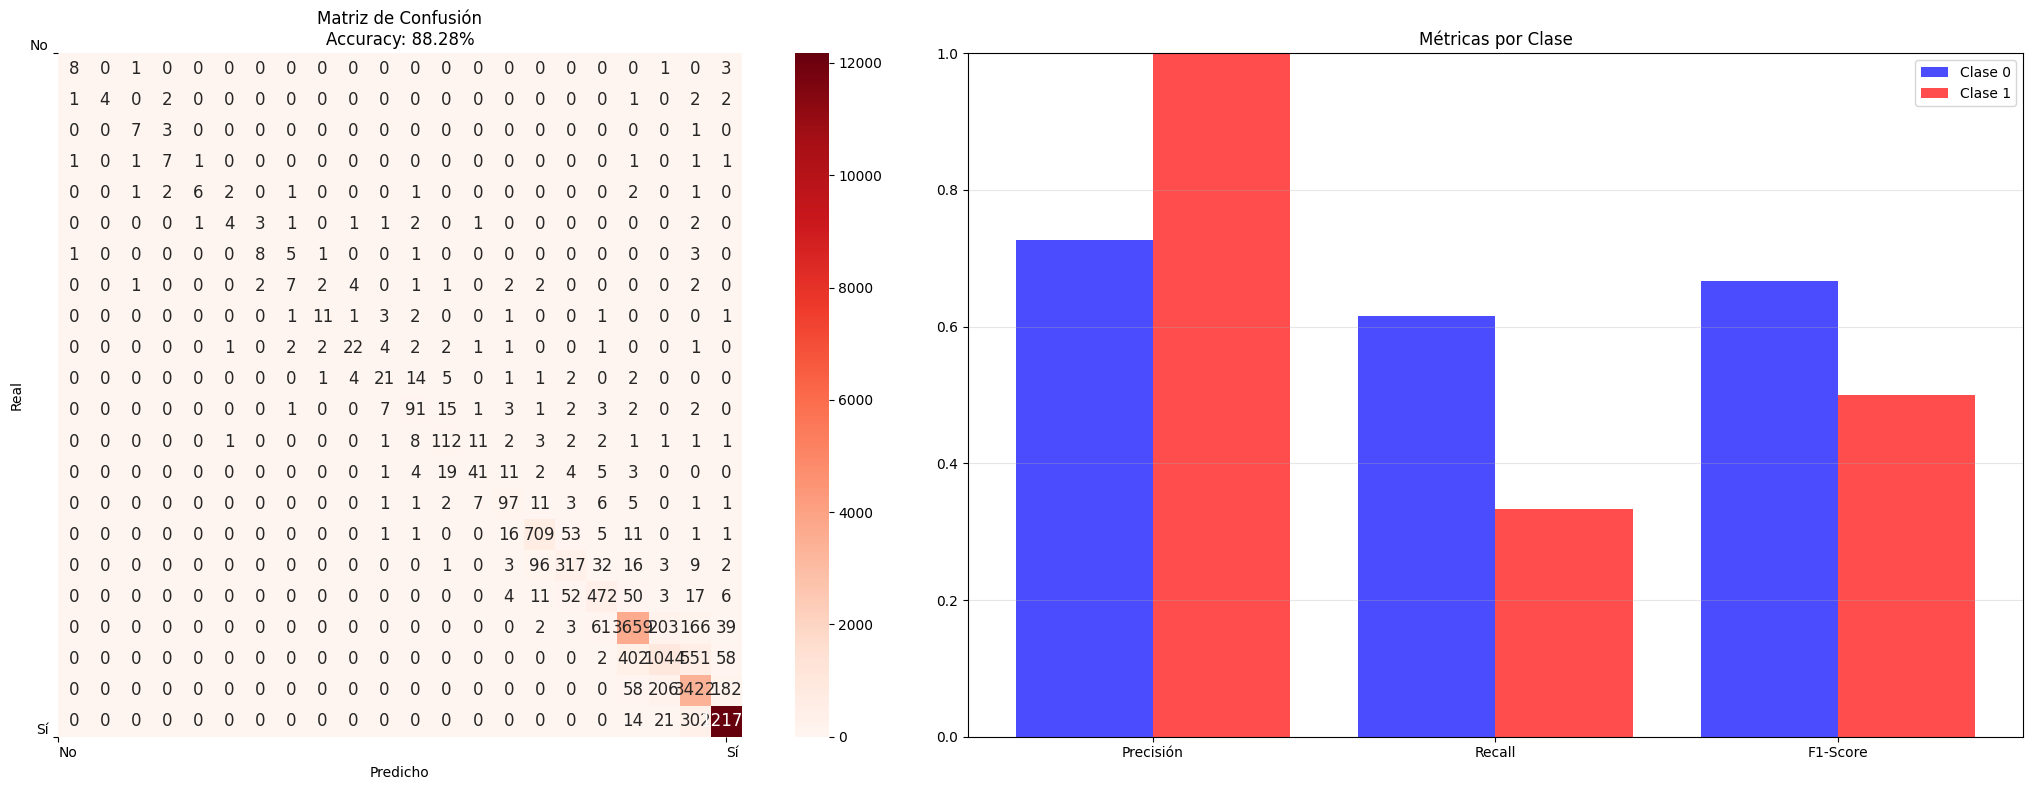

In [9]:
# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print(f"✅ Accuracy: {accuracy:.2%}")

# Crear figura más alta pero con control de tamaño de visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No', 'Sí'],
            yticklabels=['No', 'Sí'],
            ax=ax1, annot_kws={'size': 12}, cbar=True, square=True)

# Colocar ticks en los bordes (extremos)
ax1.set_xticks([0, cm.shape[1]-0.5])   # posiciones muy cerca de los extremos izquierdo/derecho
ax1.set_xticklabels(['No', 'Sí'], rotation=0, ha='left')
ax1.xaxis.set_label_position('bottom')
ax1.xaxis.tick_bottom()

# Para el eje Y (si se quiere en extremos superior/inferior):
ax1.set_yticks([0, cm.shape[0]])
ax1.set_yticklabels(['No', 'Sí'], rotation=0, va='bottom')

ax1.set_title(f'Matriz de Confusión\nAccuracy: {accuracy:.2%}')
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')

# Métricas por clase
metrics = ['Precisión', 'Recall', 'F1-Score']
clase_0 = [report['0']['precision'], report['0']['recall'], report['0']['f1-score']]
clase_1 = [report['1']['precision'], report['1']['recall'], report['1']['f1-score']]

x = range(len(metrics))
ax2.bar(x, clase_0, width=0.4, label='Clase 0', alpha=0.7, color='blue')
ax2.bar([i + 0.4 for i in x], clase_1, width=0.4, label='Clase 1', alpha=0.7, color='red')
ax2.set_xticks([i + 0.2 for i in x])
ax2.set_xticklabels(metrics)
ax2.legend()
ax2.set_title('Métricas por Clase')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [10]:
#Usar el modelo entrenado
joblib.dump(rf_model, "../backend/rf_model_nsl_kdd.pkl")
print("✅ Modelo guardado como rf_model_nsl_kdd.pkl")

✅ Modelo guardado como rf_model_nsl_kdd.pkl


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de vuelta a DataFrame para mantener nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Ahora puedes continuar con tu código original
attack_counts = train_df['label'].value_counts().to_dict()

# Guardar columnas como JSON
columns = list(X_train_scaled.columns)
with open("../backend/columns.json", "w") as f:
    json.dump(columns, f)

print(f"✅ Datos escalados y guardados. Dimensiones: {X_train_scaled.shape}")

✅ Datos escalados y guardados. Dimensiones: (100778, 42)


In [12]:
# Crear y guardar label_encoder_y
label_encoder_y = LabelEncoder()
y_encoded = label_encoder_y.fit_transform(y)
joblib.dump(label_encoder_y, '../backend/label_encoder_y.pkl')

print("✅ label_encoder_y.pkl creado y guardado")
print(f"Classes: {label_encoder_y.classes_}")

✅ label_encoder_y.pkl creado y guardado
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
